# Determine Yield Point
* Contributor: Martin Diehl (https://martin-diehl.net)
* DAMASK version: 3.1.0
* Prerequisites (data): DADF5 results file with 1. Piola-Kirchhoff stress ('P') and deformation gradient ('F')

In [1]:
%matplotlib inline

In [2]:
import damask
import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True # set to False if Latex is not installed

In [3]:
# adjust to your situation
result_file = 'determine_yield_point/20grains16x16x16_tensionX_material.hdf5'
idx = [0,0] # xx-component

## Procedure
The yield point is determined as the intersection of a line with the slope of the elastic response shifted by 0.2%.
To ensure that the solution is insensitive to the selected time stepping, stress and strain are resampled.

In [4]:
result = damask.Result(result_file)
result.add_strain()
result.add_stress_Cauchy()

In [5]:
sigma = np.array([np.average(s[:,idx[0],idx[1]]) for s in result.place('sigma').values()])
epsilon = np.array([np.average(e[:,idx[0],idx[1]]) for e in result.place('epsilon_V^0.0(F)').values()])
E_load = sigma[1]/epsilon[1]

In [6]:
# interpolate and resample, mainly useful for a coarse time discretization
sigma_interpolated = interpolate.CubicSpline(epsilon,sigma)
epsilon_resampled = np.linspace(epsilon[0],epsilon[-1],num=1000)
sigma_resampled = sigma_interpolated(epsilon_resampled)

In [7]:
i = np.argmax(sigma_resampled < (epsilon_resampled - 0.002)*E_load)

In [8]:
print(f"Young's modulus in loading direction: {round(E_load/1e9)} GPa")
print(f'Yield stress: {round(sigma_resampled[i]/1e6)} MPa at a strain of {round(epsilon_resampled[i]*100,3)} %')

Young's modulus in loading direction: 65 GPa
Yield stress: 77 MPa at a strain of 0.325 %


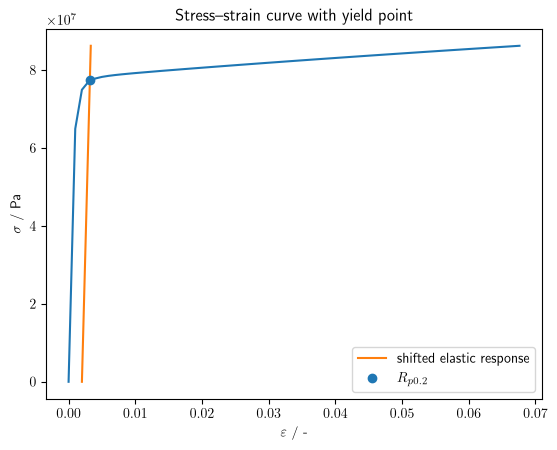

In [9]:
fig, ax = plt.subplots()
ax.plot(epsilon,sigma)
ax.plot([0.002,0.002+sigma[-1]/E_load],[0,sigma[-1]],label='shifted elastic response')
ax.scatter(epsilon_resampled[i],sigma_resampled[i],label=r'$R_{p 0.2}$',zorder=2)

ax.set_title('Stress–strain curve with yield point')
ax.set_xlabel(r'$\varepsilon$ / -')
ax.set_ylabel(r'$\sigma$ / Pa')
ax.legend()

plt.show()